# Primary Analysis

**Phase 4.** Does either campaign beat no campaign?

> ### This is where the outcome blind ends
>
> Every analysis before this one was pooled across arms or restricted to
> pre-treatment covariates. This notebook computes treatment effects. That is the
> intended step, and it is safe precisely because `PRE_REGISTRATION.md` was
> committed, tagged `pre-registration-v1`, and verified on the remote *before* any
> of this existed. Every estimator, threshold and correction below was fixed in
> advance and is publicly timestamped.

§5 of the pre-registration says: *"the analysis code implements this table and
nothing else."* That is the constraint this notebook operates under. Nothing is
selected, tuned, or reconsidered after seeing an estimate.

What was fixed in advance:

| Element | Committed value |
|---|---|
| Primary metric | `conversion` |
| Primary estimator | Lin-adjusted OLS, mean-centred covariates + treatment interactions, **HC2** SE |
| Sensitivity | Unadjusted two-proportion z + 10,000-resample bootstrap |
| Multiplicity | BH at q = 0.05 within the 2-test primary family |
| Decision threshold | 0.30 pp |

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
from src.db import get_engine
from src.inference import (
    DECISION_THRESHOLD_PP, Q_PRIMARY, WINSOR_CAP, TREATMENTS,
    bh_correct, bootstrap_diff, lin_estimate, load_analysis_frame,
    load_arm_metrics, spend_analysis, two_proportion_z,
)

pd.set_option("display.width", 130)
engine = get_engine()
df = load_analysis_frame(engine)
len(df)

64000

## 1. The descriptive picture

Arm-level metrics from `sql/05_primary_metrics.sql`. Descriptive only — no
inference is being drawn here.

In [2]:
agg = load_arm_metrics(engine)
agg[["n", "conversions", "conversion_rate", "visit_rate", "spend_mean", "n_capped"]]

,n,conversions,conversion_rate,visit_rate,spend_mean,n_capped
segment,,,,,,
Mens E-Mail,21307,267,0.012531,0.182757,1.422617,30
No E-Mail,21306,122,0.005726,0.106167,0.652789,11
Womens E-Mail,21387,189,0.008837,0.151400,1.077202,23


Note `n_capped` sums to **64**, exactly matching §6. The winsorisation cap is read
from the pre-registration as a constant rather than recomputed from the data —
recomputing a percentile at analysis time is how a "pre-specified" threshold
quietly drifts to fit the result.

## 2. Primary result

Lin-adjusted OLS with HC2 robust errors. With covariates centred over the full
64,000, the coefficient on each treatment dummy *is* that arm's average treatment
effect against control.

**Absolute percentage points first, relative lift second.** On a 0.57% control
base rate, leading with relative lift is the single most common way experiment
results mislead — a "+118% lift" and a "+0.68 pp lift" are the same number, and
only one of them tells you how many customers that is.

In [3]:
primary = lin_estimate(df, "conversion")
reject, p_adj = bh_correct([e.p_value for e in primary], Q_PRIMARY)

pd.DataFrame([{
    "contrast": e.contrast,
    "effect (pp)": round(e.effect_pp, 4),
    "95% CI low": round(e.ci_low * 100, 4),
    "95% CI high": round(e.ci_high * 100, 4),
    "relative %": round(e.relative_pct, 1),
    "p": f"{e.p_value:.2e}",
    "BH-adj p": f"{pa:.2e}",
    f"sig @ q={Q_PRIMARY}": bool(r),
} for e, r, pa in zip(primary, reject, p_adj)])

,contrast,effect (pp),95% CI low,95% CI high,relative %,p,BH-adj p,sig @ q=0.05
0,Mens E-Mail vs Control,0.6750,0.4948,0.8551,117.9,2.10e-13,4.21e-13,True
1,Womens E-Mail vs Control,0.3135,0.1517,0.4753,54.8,1.46e-04,1.46e-04,True


**Both campaigns beat control**, and not marginally.

- **Mens: +0.675 pp** (95% CI +0.495 to +0.855), a **+118%** relative lift on a
  0.573% base.
- **Womens: +0.314 pp** (95% CI +0.152 to +0.475), **+55%** relative.

Both survive BH correction at q = 0.05 with room to spare. Both point estimates
clear the pre-registered 0.30 pp decision threshold — Mens comfortably, Womens by
a margin narrow enough to be worth stating plainly: at +0.314 pp it clears 0.30 pp
by 0.014 pp, and the lower CI bound sits at 0.152 pp, *below* the threshold. The
rule was written on the point estimate, so Womens passes; but the evidence that
its true effect exceeds 0.30 pp is much weaker than the pass/fail line suggests.

## 3. Sensitivity: does the unadjusted estimate agree?

§5 pre-commits that material disagreement is reported as a finding, and that the
adjusted estimate governs regardless. Three estimators, same quantity.

In [4]:
unadj = two_proportion_z(df, "conversion")
rows = []
for a, u in zip(primary, unadj):
    arm = a.contrast.split(" vs ")[0]
    b = bootstrap_diff(df, "conversion", arm)
    rows.append({
        "contrast": a.contrast,
        "Lin-adjusted (pp)": round(a.effect_pp, 4),
        "unadjusted z (pp)": round(u.effect_pp, 4),
        "bootstrap (pp)": round(b["effect"] * 100, 4),
        "SE adj": round(a.se * 100, 4),
        "SE unadj": round(u.se * 100, 4),
        "SE ratio": round(a.se / u.se, 4),
    })
pd.DataFrame(rows)

,contrast,Lin-adjusted (pp),unadjusted z (pp),bootstrap (pp),SE adj,SE unadj,SE ratio
0,Mens E-Mail vs Control,0.6750,0.6805,0.6805,0.0919,0.0921,0.9983
1,Womens E-Mail vs Control,0.3135,0.3111,0.3111,0.0825,0.0823,1.0034


**No disagreement.** All three estimators land within 0.006 pp of each other, and
the bootstrap interval matches the analytic z interval to within 0.003 pp. Nothing
to report as a discrepancy.

### The covariate adjustment bought essentially nothing

The SE ratio is **0.998** and **1.003**. The Lin adjustment — eight pre-treatment
covariates plus treatment interactions, 48 parameters — reduced the standard error
by about **0.2%** on one contrast and *increased* it slightly on the other.

This is worth stating clearly because §5.1 explicitly speculated the other way:

> It is entirely possible that the pre-treatment covariates predict `conversion`
> better than `history` predicts `spend`, making the *primary* metric the larger
> variance-reduction win. Whichever way it lands is reported as found.

It landed as *no*. Prior-year purchase behaviour barely predicts who converts in a
two-week window, just as it barely predicts how much they spend (ρ = 0.0217). The
adjustment was still the right thing to pre-register — Lin (2013) guarantees it
cannot hurt asymptotically, so committing to it carried no risk — but the honest
report is that it did not help.

Committing to the adjusted estimator in advance is what makes this reportable at
all. Had the estimator been chosen after seeing that the unadjusted SE was
marginally smaller for Mens, the choice would have been unfalsifiable.

## 4. Coherence check: `visit`

§4 designates `visit` a well-powered directional check, and pre-commits that a
positive `conversion` effect alongside a null or negative `visit` effect is a
coherence problem worth reporting rather than averaging away.

In [5]:
pd.DataFrame([{
    "contrast": e.contrast,
    "effect (pp)": round(e.effect_pp, 4),
    "95% CI low": round(e.ci_low * 100, 4),
    "95% CI high": round(e.ci_high * 100, 4),
    "relative %": round(e.relative_pct, 1),
    "p": f"{e.p_value:.2e}",
} for e in lin_estimate(df, "visit")])

,contrast,effect (pp),95% CI low,95% CI high,relative %,p
0,Mens E-Mail vs Control,7.6023,6.9491,8.2556,71.6,3.74e-115
1,Womens E-Mail vs Control,4.5466,3.9206,5.1725,42.8,5.43e-46


**Fully coherent.** Mens **+7.60 pp** on visits, Womens **+4.55 pp**, both
overwhelmingly significant and both ordered the same way as conversion. The
campaigns drive traffic, and some of that traffic converts. No contradiction to
flag.

## 5. Spend, and what actually drives it

Raw and winsorised reported side by side per §6, regardless of whether they agree.
Medians are not used: `spend` is zero at the median in every arm, so a median test
has no power by construction.

In [6]:
sp = spend_analysis(df)
sp[["contrast", "raw_diff", "raw_ci_low", "raw_ci_high",
    "wins_diff", "wins_ci_low", "wins_ci_high"]].round(4)

,contrast,raw_diff,raw_ci_low,raw_ci_high,wins_diff,wins_ci_low,wins_ci_high
0,Mens E-Mail vs Control,0.7698,0.4939,1.0589,0.6592,0.4404,0.8812
1,Womens E-Mail vs Control,0.4244,0.1679,0.6790,0.3829,0.1775,0.5890


In [7]:
sp["conv_lift_pp"] = (sp.p_conv_t - sp.p_conv_c) * 100
sp["basket_change"] = sp.spend_given_conv_t - sp.spend_given_conv_c
sp[["contrast", "p_conv_c", "p_conv_t", "conv_lift_pp",
    "spend_given_conv_c", "spend_given_conv_t", "basket_change"]].round(4)

,contrast,p_conv_c,p_conv_t,conv_lift_pp,spend_given_conv_c,spend_given_conv_t,basket_change
0,Mens E-Mail vs Control,0.0057,0.0125,0.6805,114.0027,113.5269,-0.4758
1,Womens E-Mail vs Control,0.0057,0.0088,0.3111,114.0027,121.8948,7.8921


**Spend rises, and winsorising does not overturn it.** Mens **+$0.77** raw and
**+$0.66** winsorised; Womens **+$0.42** raw and **+$0.38** winsorised. Both
intervals exclude zero either way. The winsorised effects are smaller, which is
expected — capping 64 customers removes upside the treatment arms disproportionately
contained — but the conclusion is unchanged.

### The decomposition is the product story

This is the part worth carrying into the memo:

| Contrast | P(conversion) | E[spend \| conversion] |
|---|---|---|
| Mens vs Control | 0.573% → 1.253% (**+0.68 pp**) | $114.00 → $113.53 (**−$0.47**) |
| Womens vs Control | 0.573% → 0.884% (**+0.31 pp**) | $114.00 → $121.89 (**+$7.89**) |

For the Mens campaign the entire spend effect comes from **more people buying**.
Basket size is flat — $113.53 against $114.00, a difference of less than half a
dollar on a $114 basket. The campaign acquires purchasers; it does not change what
a purchaser spends.

Womens shows a +$7.89 conditional increase, but that rests on **189 converters**
against 122 in control, and no interval is placed on it here. It should be read as
suggestive at most, not as evidence that the Womens campaign lifts basket size.

The distinction matters because the two stories imply different follow-ups. "More
people bought" points at reach and targeting. "Buyers spent more" would point at
merchandising and basket construction. Here the answer is the first one.

## 6. Bootstrapped distributions

10,000 stratified resamples per contrast — each arm resampled to its own observed
size, since that is what randomisation fixed.

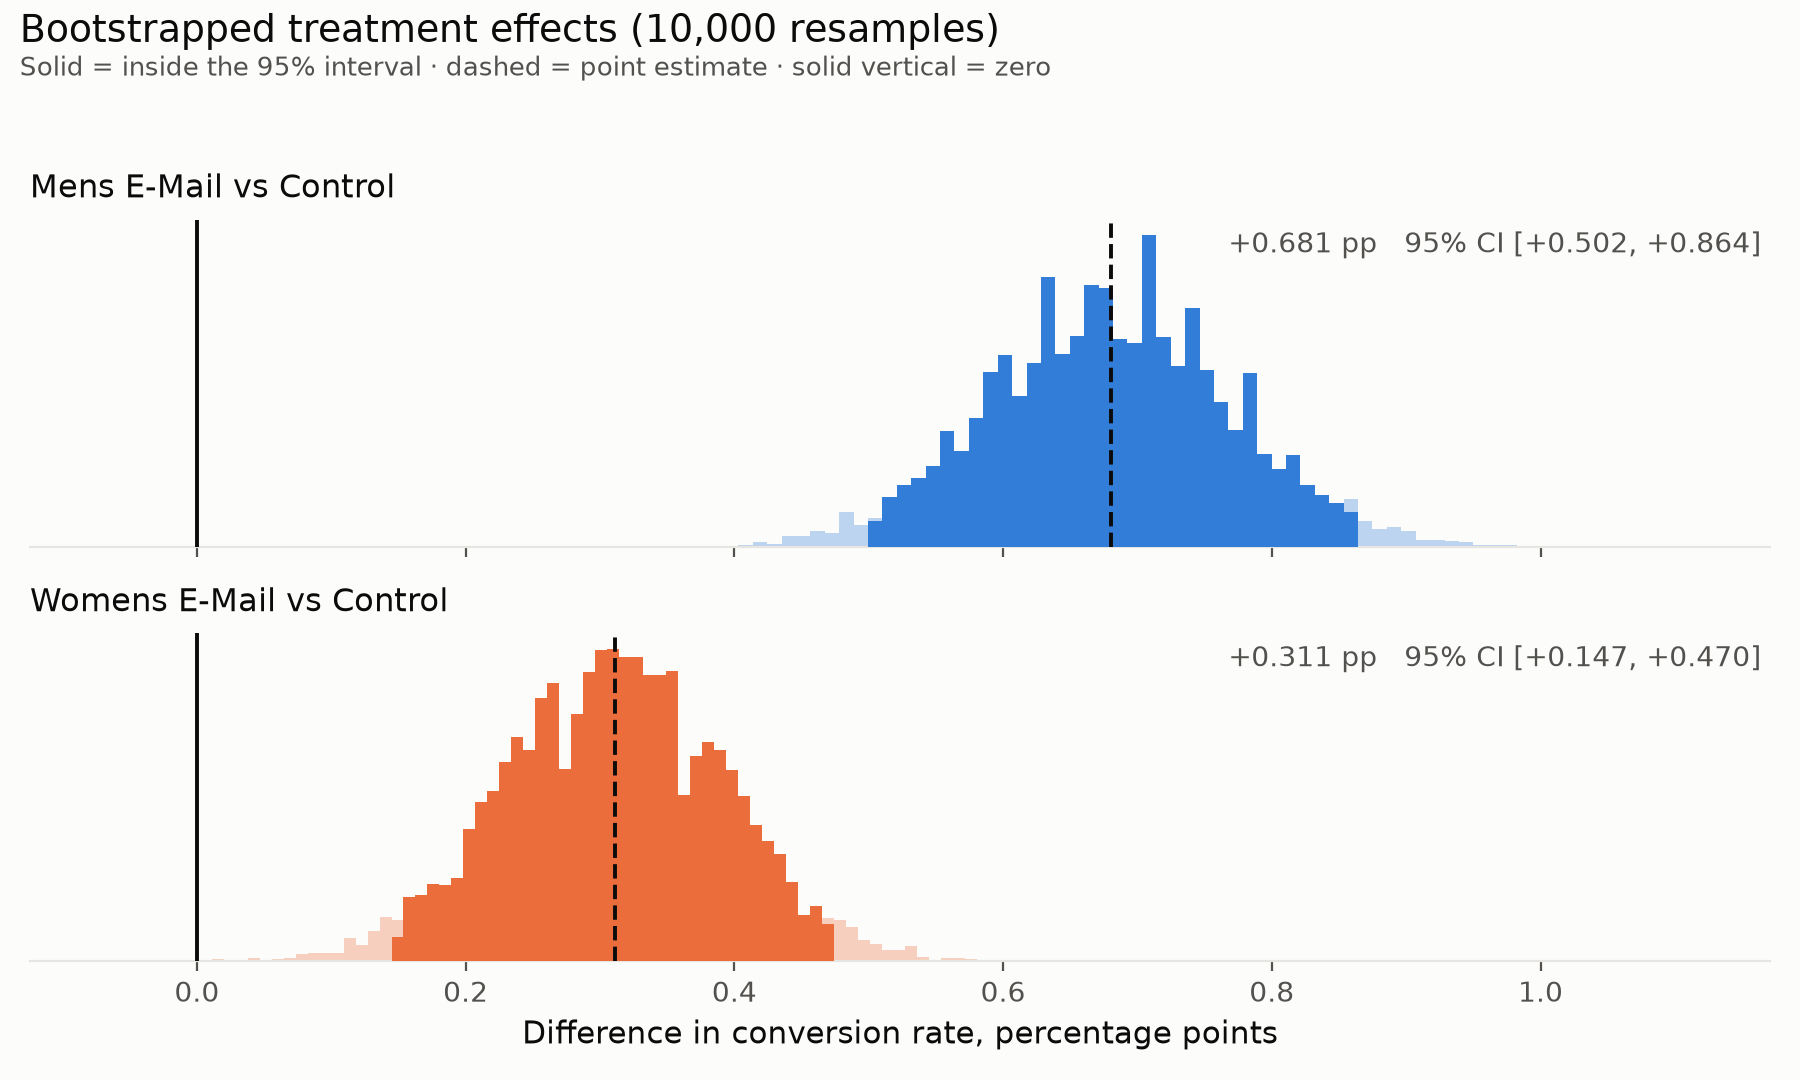

In [8]:
from IPython.display import Image
from src.db import PROJECT_ROOT
Image(str(PROJECT_ROOT / "figures" / "bootstrap_conversion.png"), width=880)

## 7. Applying the decision rule

§10 is applied mechanically. Conditions 1–3 require **interaction tests**, which are
Phase 6 — so what Phase 4 can settle is the *"otherwise"* clause: does either arm
beat control on the primary family?

In [9]:
pd.DataFrame([{
    "contrast": e.contrast,
    "effect (pp)": round(e.effect_pp, 4),
    "BH-significant": bool(r),
    f">= {DECISION_THRESHOLD_PP} pp": e.effect_pp >= DECISION_THRESHOLD_PP,
    "passes pooled clause": bool(r) and e.effect_pp >= DECISION_THRESHOLD_PP,
} for e, r in zip(primary, reject)])

,contrast,effect (pp),BH-significant,>= 0.3 pp,passes pooled clause
0,Mens E-Mail vs Control,0.6750,True,True,True
1,Womens E-Mail vs Control,0.3135,True,True,True


## Verdict — provisional

**Both campaigns beat no campaign on the primary metric.** The Mens campaign is
roughly twice as effective as the Womens campaign in absolute terms: **+0.675 pp**
against **+0.314 pp**.

Applying §10's "otherwise" clause, the pooled recommendation is the **Mens
campaign**.

**This is provisional, and the caveat is not a formality.** The business question
was never "which single campaign should everyone get" — it was *which audience
should receive which campaign*. That is a claim about effects **differing** across
subgroups, and it cannot be answered from a pooled average no matter how
significant. Phase 6 runs the pre-registered interaction tests. If any of them
clears BH correction at q = 0.10, the recommendation becomes a targeting rule
rather than a single campaign.

Three things this result does **not** establish:

- **Not that Mens beats Womens.** That contrast lives in the secondary family and
  has not been tested here.
- **Not that the Mens campaign is right for everyone.** A pooled average can hide
  a subgroup the campaign actively hurts. That is Phase 6's job.
- **Not anything about long-run value.** There is no unsubscribe, complaint or
  fatigue metric in this dataset (§11.1), and the window is two weeks. A campaign
  that lifts purchases while burning list health would look identical to this one
  in these data.